In [13]:
import pandas as pd

colunas_alvo = [
    'ban_development',
    'ban_testing',
    'ban_production',
    'ban_acquisition',
    'ban_possession',
    'ban_station',
    'ban_transfer',
    'ban_use',
    'ban_disposal',
    'restriction_development',
    'testing_restriction',       # note: inconsistent naming in the dataset
    'restriction_production',
    'restriction_acquisition',
    'restriction_possession',
    'restriction_transfer',
    'restriction_use',
    'restriction_disposal',
    'obligations_timeframe_type'
]

outras_colunas = [
    'agreement_id',
    'item_type',
    'item',
    'weapon_item_definition',
    'c_weapon_item_definition',
    'timeframe_set_time',
    'timeframe_other',
    'c_obligations_timeframe',
    'timeframe_phases',
    'c_timeframe_phases',
    'c_phases'
]

all_columns_to_keep = outras_colunas + colunas_alvo

df = pd.read_csv('data/amcdata_weapons_facilities_V2.csv', encoding = 'latin-1')

# Preprocess data
df['item'] = df['item'].str.strip().str.lower()
df = df[df['item'].notna() & (df['item'] != '')]
df['item'] = df['item'].str.replace(',', " ")
df['item'] = df['item'].str.replace(r's$', '', regex=True)
df = df[df['summary_category'] != 1]

df = df[all_columns_to_keep]

# Extract all unique items
item_lst = list(df['item'].unique())
len(item_lst)

218

In [26]:
# Load in the dual use mapping
dual_use_mapping_df = pd.read_csv('weapon_dual_use_labels.csv', encoding= 'latin-1')

# merge this mapping with the original data on the item name
df = pd.merge(df, dual_use_mapping_df, left_on = 'item', right_on = 'weapon_category', how = 'inner')
df.to_csv('database_with_dualuse_mapping.csv', index=False, encoding='latin-1')
df.head(5)

,agreement_id,item_type,item,weapon_item_definition,c_weapon_item_definition,timeframe_set_time,timeframe_other,c_obligations_timeframe,timeframe_phases,c_timeframe_phases,...,obligations_timeframe_type,weapon_category_x,dual_use_x,rationale_x,weapon_category_y,dual_use_y,rationale_y,weapon_category,dual_use,rationale
0,40,1.0,weapons general,99,NaN,NaN,NaN,Assumed directly upon force given no explicit ...,0.0,NaN,...,0.0,weapons general,0,Purely military concept; not in dual-use list,weapons general,0,Purely military concept; not in dual-use list,weapons general,0,Purely military concept; not in dual-use list
1,50,1.0,nuclear weapon,99,NaN,NaN,NaN,Assumed directly upon force given no explicit ...,0.0,NaN,...,0.0,nuclear weapon,0,Weapon system; nuclear MATERIALS are dual-use ...,nuclear weapon,0,Weapon system; nuclear MATERIALS are dual-use ...,nuclear weapon,0,Weapon system; nuclear MATERIALS are dual-use ...
2,50,3.0,radioactive waste,99,NaN,NaN,NaN,Assumed directly upon force given no explicit ...,0.0,NaN,...,0.0,radioactive waste,0,Not a controlled category in the dual-use list,radioactive waste,0,Not a controlled category in the dual-use list,radioactive waste,0,Not a controlled category in the dual-use list
3,50,1.0,weapons general,NaN,NaN,NaN,NaN,Assumed directly upon force given no explicit ...,0.0,NaN,...,0.0,weapons general,0,Purely military concept; not in dual-use list,weapons general,0,Purely military concept; not in dual-use list,weapons general,0,Purely military concept; not in dual-use list
4,90,1.0,nuclear weapon,99,NaN,NaN,NaN,Assumed directly upon force given no explicit ...,0.0,NaN,...,0.0,nuclear weapon,0,Weapon system; nuclear MATERIALS are dual-use ...,nuclear weapon,0,Weapon system; nuclear MATERIALS are dual-use ...,nuclear weapon,0,Weapon system; nuclear MATERIALS are dual-use ...


In [15]:
df[df['dual_use'] == 1].head(5)

,agreement_id,item_type,item,weapon_item_definition,c_weapon_item_definition,timeframe_set_time,timeframe_other,c_obligations_timeframe,timeframe_phases,c_timeframe_phases,...,restriction_production,restriction_acquisition,restriction_possession,restriction_transfer,restriction_use,restriction_disposal,obligations_timeframe_type,weapon_category,dual_use,rationale
5,90,3.0,fissile material,99,NaN,NaN,NaN,Assumed directly upon force given no explicit ...,0.0,NaN,...,1,0,0,1,1,0,0.0,fissile material,1,0C002 (Special fissile materials) â explicit...
7,70,3.0,nuclear material,99,NaN,NaN,NaN,Assumed directly upon force given no explicit ...,0.0,NaN,...,0,0,0,0,1,0,0.0,nuclear material,1,Category 0 covers natural uranium / depleted u...
22,130,3.0,microbial/other biological agent,99,NaN,Nine months,NaN,Ibid. Article II. Each State Party to this Con...,0.0,NaN,...,1,0,1,1,0,0,1.0,microbial/other biological agent,1,1C351 â biological agents (pathogens) contro...
23,130,3.0,toxin,99,NaN,Nine months,NaN,Ibid. Article II. Each State Party to this Con...,0.0,NaN,...,1,0,1,1,0,0,1.0,toxin,1,1C351.d and 1C350 â toxins controlled as dua...
37,290,1.0,fissile material,99,NaN,NaN,NaN,Assumed directly upon force given no explicit ...,0.0,NaN,...,0,0,0,0,1,0,0.0,fissile material,1,0C002 (Special fissile materials) â explicit...


<Axes: >

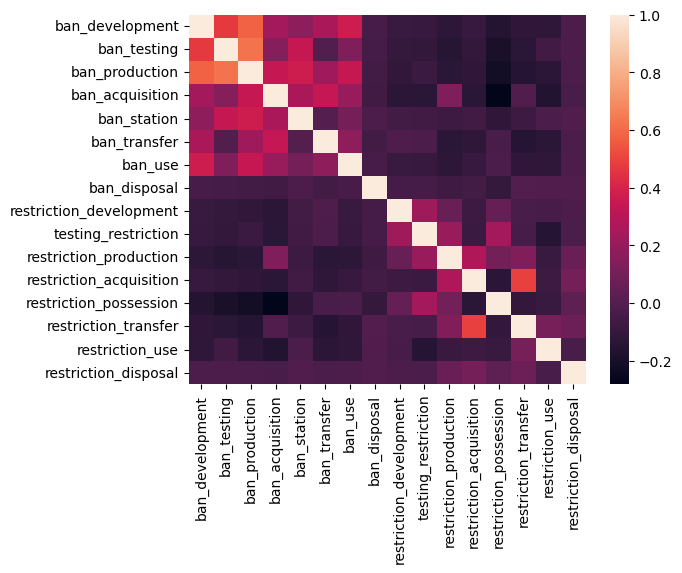

In [23]:
import seaborn as sns

# Separate ban and restriction columns
ban_cols = [c for c in df.columns if (c.startswith('ban_') and c not in 'ban_possession')]
restriction_cols = [c for c in df.columns if 'restriction' in c]

# calculate a correlation matrix
corr_df = df[ban_cols + restriction_cols].corr(method='pearson')

sns.heatmap(corr_df)

<Axes: >

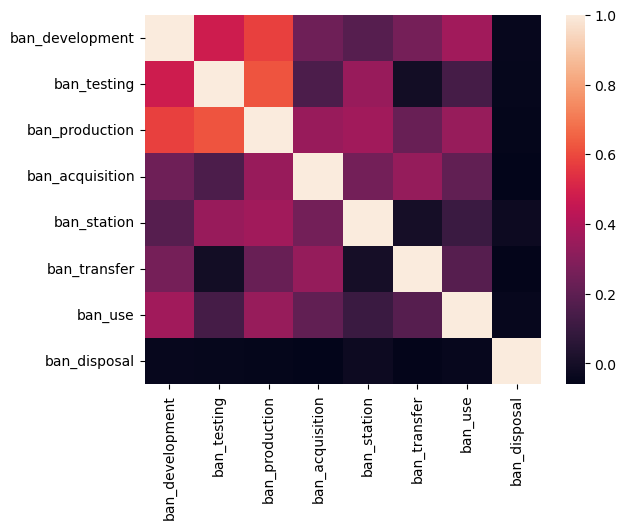

In [24]:
# calculate a correlation matrix
corr_df = df[ban_cols].corr(method='pearson')

sns.heatmap(corr_df)